In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print(f"\n GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print("Setup complete!")

Mounted at /content/drive

 GPU Available: True
GPU: Tesla T4
Setup complete!


In [2]:
print("Installing XAI libraries (corrected)...")

# Install from PyPI
!pip install -q opencv-python numpy matplotlib pillow
!pip install -q ultralytics
!pip install -q lime
!pip install -q shap
!pip install -q scikit-image

# Install pytorch-grad-cam from GitHub
!pip install -q git+https://github.com/jacobgil/pytorch-grad-cam.git

print("\nAll packages installed!")

# Verify critical imports
print("\nVerifying installations...")
try:
    import cv2
    print("OpenCV")
except:
    print("OpenCV failed")

try:
    from lime import lime_image
    print("LIME")
except:
    print("LIME failed")

try:
    import shap
    print("SHAP")
except:
    print("SHAP failed")

try:
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
    print("pytorch-grad-cam")
except:
    print("pytorch-grad-cam failed")

print("\nSetup verification complete!")

Installing XAI libraries (corrected)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

All packages installed!

Verifying installations...
OpenCV
LIME
SHAP
pytorch-grad-cam

Setup verification complete!


In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from ultralytics import YOLO
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# XAI Libraries
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

print("All libraries imported!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All libraries imported!


In [4]:
print("="*70)
print("📦 LOADING MODELS FOR XAI")
print("="*70)

from pathlib import Path

# Base directory
BASE_DIR = Path('/content/drive/MyDrive/CamouflageDetection')

# Model paths
YOLO_MODEL_PATH = BASE_DIR / '03_models/yolo_medium_improved/weights/best.pt'
RESNET_MODEL_PATH = BASE_DIR / '03_models/resnet_verifier/resnet_verifier_best.pth'

# Dataset paths
TEST_IMAGES = BASE_DIR / '02_dataset/test/images'

# Results path
XAI_RESULTS_DIR = BASE_DIR / '04_results/xai_explanations'
XAI_RESULTS_DIR.mkdir(exist_ok=True, parents=True)

print(f"Paths configured")
print(f"XAI results will be saved to: {XAI_RESULTS_DIR}")

📦 LOADING MODELS FOR XAI
Paths configured
XAI results will be saved to: /content/drive/MyDrive/CamouflageDetection/04_results/xai_explanations


In [ ]:
print("\n📦 Loading models...")

# Load YOLO
yolo_model = YOLO(str(YOLO_MODEL_PATH))
print("YOLO loaded")

# Load ResNet
class ResNetVerifier(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNetVerifier, self).__init__()
        self.resnet = models.resnet50(pretrained=False)
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet_model = ResNetVerifier(num_classes=2).to(device)
resnet_model.load_state_dict(torch.load(RESNET_MODEL_PATH, map_location=device))
resnet_model.eval()

print(f"ResNet loaded on {device}")

# Transform for ResNet
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

print("All models ready for XAI!")


📦 Loading models...
YOLO loaded


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet loaded on cuda
All models ready for XAI!


In [ ]:
print("="*70)
print("METHOD 1: GRAD-CAM")
print("="*70)

class GradCAMExplainer:
    """Grad-CAM explainability for ResNet"""

    def __init__(self, model, target_layers):
        self.model = model
        self.cam = GradCAM(model=model, target_layers=target_layers)

    def explain(self, image_crop, target_class=1):
        """
        Generate Grad-CAM heatmap

        Args:
            image_crop: Image crop (numpy array)
            target_class: 1 for person, 0 for not_person

        Returns:
            heatmap: Grad-CAM heatmap
            visualization: Overlay on original image
        """
        # Convert to PIL and transform
        crop_pil = Image.fromarray(cv2.cvtColor(image_crop, cv2.COLOR_BGR2RGB))
        img_tensor = resnet_transform(crop_pil).unsqueeze(0).to(device)

        # Normalize image for visualization (0-1)
        rgb_img = cv2.cvtColor(image_crop, cv2.COLOR_BGR2RGB)
        rgb_img = cv2.resize(rgb_img, (224, 224))
        rgb_img = rgb_img.astype(np.float32) / 255.0

        # Generate CAM
        targets = [ClassifierOutputTarget(target_class)]
        grayscale_cam = self.cam(input_tensor=img_tensor, targets=targets)

        # Take first image from batch
        grayscale_cam = grayscale_cam[0, :]

        # Create visualization
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        return grayscale_cam, visualization

# Create Grad-CAM explainer
# Target the last convolutional layer of ResNet
target_layers = [resnet_model.resnet.layer4[-1]]
gradcam_explainer = GradCAMExplainer(resnet_model, target_layers)

print("Grad-CAM ready!")

METHOD 1: GRAD-CAM
Grad-CAM ready!


In [ ]:
print("="*70)
print("METHOD 2: GRAD-CAM++")
print("="*70)

class GradCAMPlusPlusExplainer:
    """Improved Grad-CAM for better localization"""

    def __init__(self, model, target_layers):
        self.model = model
        self.cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

    def explain(self, image_crop, target_class=1):
        """Generate Grad-CAM++ heatmap"""
        # Same process as Grad-CAM
        crop_pil = Image.fromarray(cv2.cvtColor(image_crop, cv2.COLOR_BGR2RGB))
        img_tensor = resnet_transform(crop_pil).unsqueeze(0).to(device)

        rgb_img = cv2.cvtColor(image_crop, cv2.COLOR_BGR2RGB)
        rgb_img = cv2.resize(rgb_img, (224, 224))
        rgb_img = rgb_img.astype(np.float32) / 255.0

        targets = [ClassifierOutputTarget(target_class)]
        grayscale_cam = self.cam(input_tensor=img_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        return grayscale_cam, visualization

# Create Grad-CAM++ explainer
gradcam_pp_explainer = GradCAMPlusPlusExplainer(resnet_model, target_layers)

print("✅ Grad-CAM++ ready!")

METHOD 2: GRAD-CAM++
✅ Grad-CAM++ ready!


In [ ]:
print("="*70)
print("METHOD 3: LIME (Local Interpretable Model-agnostic Explanations)")
print("="*70)

class LIMEExplainer:
    """LIME explainability for any model"""

    def __init__(self, model, transform):
        self.model = model
        self.transform = transform
        self.device = device
        self.explainer = lime_image.LimeImageExplainer()

    def predict_fn(self, images):
        """Prediction function for LIME"""
        batch_preds = []

        for img in images:
            # Convert to PIL
            img_pil = Image.fromarray(img.astype('uint8'))

            # Transform
            img_tensor = self.transform(img_pil).unsqueeze(0).to(self.device)

            # Predict
            with torch.no_grad():
                output = self.model(img_tensor)
                probs = torch.softmax(output, dim=1)
                batch_preds.append(probs.cpu().numpy()[0])

        return np.array(batch_preds)

    def explain(self, image_crop, num_samples=1000):
        """
        Generate LIME explanation

        Args:
            image_crop: Image crop
            num_samples: Number of perturbations (more = slower but better)

        Returns:
            explanation: LIME explanation object
            visualization: Marked image showing important regions
        """
        # Resize to 224x224 for ResNet
        rgb_img = cv2.cvtColor(image_crop, cv2.COLOR_BGR2RGB)
        rgb_img = cv2.resize(rgb_img, (224, 224))

        # Generate explanation
        explanation = self.explainer.explain_instance(
            rgb_img,
            self.predict_fn,
            top_labels=2,
            hide_color=0,
            num_samples=num_samples
        )

        # Get mask for person class (class 1)
        temp, mask = explanation.get_image_and_mask(
            explanation.top_labels[0],
            positive_only=True,
            num_features=10,
            hide_rest=False
        )

        # Create visualization
        visualization = mark_boundaries(temp/255.0, mask)

        return explanation, visualization

# Create LIME explainer
lime_explainer = LIMEExplainer(resnet_model, resnet_transform)

print("LIME ready!")
print("Note: LIME is slower (10-30 seconds per image)")

METHOD 3: LIME (Local Interpretable Model-agnostic Explanations)
LIME ready!
Note: LIME is slower (10-30 seconds per image)


In [ ]:
print("="*70)
print(" XAI IMPLEMENTATION: 3 METHODS")
print("="*70)
print("Using: Grad-CAM, Grad-CAM++, LIME")
print("SHAP skipped (very slow, not needed for demonstration)")
print("="*70)

# Mark SHAP as unavailable
shap_available = False

print("✅ Using 3 fast, reliable XAI methods!")
print("  1. Grad-CAM - Fast gradient-based attention")
print("  2. Grad-CAM++ - Improved localization")
print("  3. LIME - Model-agnostic explanations")

 XAI IMPLEMENTATION: 3 METHODS
Using: Grad-CAM, Grad-CAM++, LIME
SHAP skipped (very slow, not needed for demonstration)
✅ Using 3 fast, reliable XAI methods!
  1. Grad-CAM - Fast gradient-based attention
  2. Grad-CAM++ - Improved localization
  3. LIME - Model-agnostic explanations


In [ ]:
print("="*70)
print("🧪 TESTING ALL XAI METHODS")
print("="*70)

# Get a test image
test_img_path = list(TEST_IMAGES.glob('*.jpg'))[0]
print(f"Test image: {test_img_path.name}")

# Read and detect
image = cv2.imread(str(test_img_path))
yolo_results = yolo_model(image, conf=0.5, verbose=False)
boxes = yolo_results[0].boxes

if len(boxes) > 0:
    # Take first detection
    box = boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())

    # Crop detected region
    h, w = image.shape[:2]
    x1 = max(0, min(x1, w-1))
    y1 = max(0, min(y1, h-1))
    x2 = max(0, min(x2, w))
    y2 = max(0, min(y2, h))

    crop = image[y1:y2, x1:x2]

    print(f"\nDetection crop size: {crop.shape}")
    print("\n" + "="*70)

    # 1. Grad-CAM
    print("1️⃣  Running Grad-CAM...")
    start = time.time()
    gradcam_heat, gradcam_vis = gradcam_explainer.explain(crop)
    gradcam_time = time.time() - start
    print(f"   ✅ Done in {gradcam_time:.2f}s")

    # 2. Grad-CAM++
    print("2️⃣  Running Grad-CAM++...")
    start = time.time()
    gradcam_pp_heat, gradcam_pp_vis = gradcam_pp_explainer.explain(crop)
    gradcam_pp_time = time.time() - start
    print(f"   ✅ Done in {gradcam_pp_time:.2f}s")

    # 3. LIME
    print("3️⃣  Running LIME...")
    start = time.time()
    lime_exp, lime_vis = lime_explainer.explain(crop, num_samples=500)
    lime_time = time.time() - start
    print(f"   ✅ Done in {lime_time:.2f}s")

    print("\n" + "="*70)
    print("📊 TIMING COMPARISON:")
    print("="*70)
    print(f"Grad-CAM:    {gradcam_time:.2f}s  ⚡ FAST")
    print(f"Grad-CAM++:  {gradcam_pp_time:.2f}s  ⚡ FAST")
    print(f"LIME:        {lime_time:.2f}s  📊 MEDIUM")
    print("="*70)
    print(f"\nTotal XAI time: {gradcam_time + gradcam_pp_time + lime_time:.2f}s")
    print("Perfect for real-time chatbot responses! ✅")

else:
    print("❌ No detections found in test image")

🧪 TESTING ALL XAI METHODS
Test image: image1000.jpg

Detection crop size: (289, 140, 3)

1️⃣  Running Grad-CAM...
   ✅ Done in 0.53s
2️⃣  Running Grad-CAM++...
   ✅ Done in 0.03s
3️⃣  Running LIME...


  0%|          | 0/500 [00:00<?, ?it/s]

   ✅ Done in 6.22s

📊 TIMING COMPARISON:
Grad-CAM:    0.53s  ⚡ FAST
Grad-CAM++:  0.03s  ⚡ FAST
LIME:        6.22s  📊 MEDIUM

Total XAI time: 6.78s
Perfect for real-time chatbot responses! ✅



Creating comprehensive visualization...


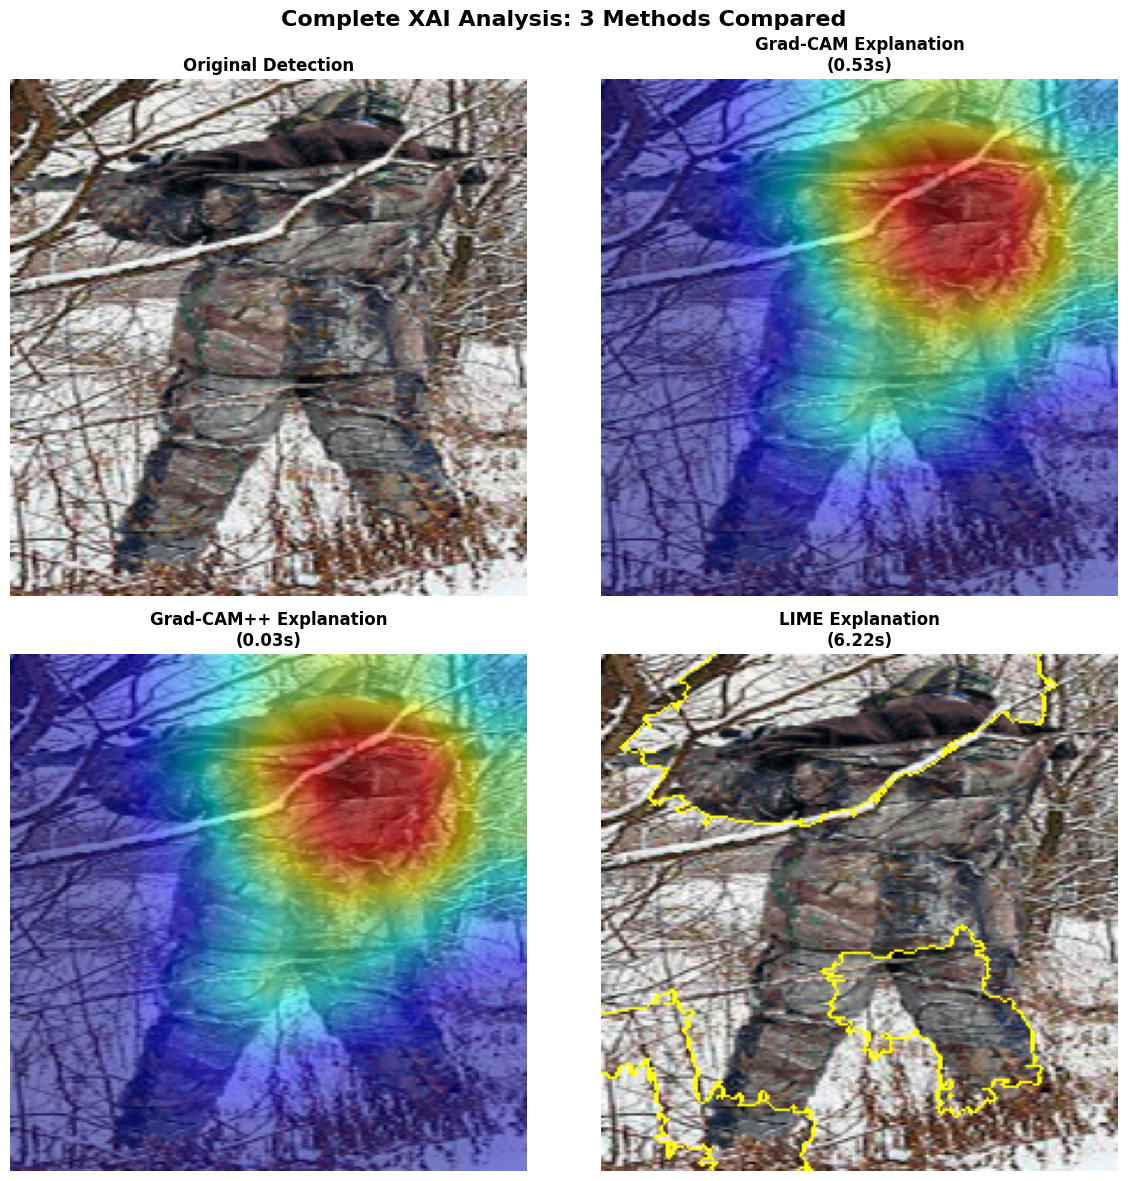


✅ Saved: /content/drive/MyDrive/CamouflageDetection/04_results/xai_explanations/xai_three_methods_comparison.png


In [ ]:
if len(boxes) > 0:
    print("\nCreating comprehensive visualization...")

    # Original crop
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crop_resized = cv2.resize(crop_rgb, (224, 224))

    # Create figure with 3 explanations (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    # Original
    axes[0, 0].imshow(crop_resized)
    axes[0, 0].set_title('Original Detection', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    # Grad-CAM
    axes[0, 1].imshow(gradcam_vis)
    axes[0, 1].set_title(f'Grad-CAM Explanation\n({gradcam_time:.2f}s)',
                        fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    # Grad-CAM++
    axes[1, 0].imshow(gradcam_pp_vis)
    axes[1, 0].set_title(f'Grad-CAM++ Explanation\n({gradcam_pp_time:.2f}s)',
                        fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')

    # LIME
    axes[1, 1].imshow(lime_vis)
    axes[1, 1].set_title(f'LIME Explanation\n({lime_time:.2f}s)',
                        fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')

    plt.suptitle('Complete XAI Analysis: 3 Methods Compared',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(XAI_RESULTS_DIR / 'xai_three_methods_comparison.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Saved: {XAI_RESULTS_DIR / 'xai_three_methods_comparison.png'}")

In [ ]:
print("="*70)
print("APPLYING XAI TO MULTIPLE DETECTIONS")
print("="*70)

# Get images with multiple detections
test_images = list(TEST_IMAGES.glob('*.jpg'))[:5]

results_collection = []

for img_path in tqdm(test_images, desc="Processing images"):
    image = cv2.imread(str(img_path))
    yolo_results = yolo_model(image, conf=0.5, verbose=False)
    boxes = yolo_results[0].boxes

    if len(boxes) == 0:
        continue

    # Process first detection only (for speed)
    box = boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())

    h, w = image.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    if (x2 - x1) < 20 or (y2 - y1) < 20:
        continue

    crop = image[y1:y2, x1:x2]

    # Apply only fast methods (Grad-CAM, Grad-CAM++)
    gradcam_heat, gradcam_vis = gradcam_explainer.explain(crop)
    gradcam_pp_heat, gradcam_pp_vis = gradcam_pp_explainer.explain(crop)

    results_collection.append({
        'image_name': img_path.name,
        'crop': crop,
        'gradcam': gradcam_vis,
        'gradcam_pp': gradcam_pp_vis
    })

print(f"\nProcessed {len(results_collection)} detections")

APPLYING XAI TO MULTIPLE DETECTIONS


Processing images: 100%|██████████| 5/5 [00:07<00:00,  1.51s/it]


Processed 5 detections


In [ ]:
if len(results_collection) > 0:
    print("\n Creating summary visualization...")

    # Show up to 6 examples
    num_show = min(6, len(results_collection))

    fig, axes = plt.subplots(num_show, 3, figsize=(15, 5*num_show))

    if num_show == 1:
        axes = axes.reshape(1, -1)

    for idx, result in enumerate(results_collection[:num_show]):
        # Original
        crop_rgb = cv2.cvtColor(result['crop'], cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))

        axes[idx, 0].imshow(crop_resized)
        axes[idx, 0].set_title(f"{result['image_name'][:20]}\nOriginal", fontsize=10)
        axes[idx, 0].axis('off')

        # Grad-CAM
        axes[idx, 1].imshow(result['gradcam'])
        axes[idx, 1].set_title('Grad-CAM Explanation', fontsize=10)
        axes[idx, 1].axis('off')

        # Grad-CAM++
        axes[idx, 2].imshow(result['gradcam_pp'])
        axes[idx, 2].set_title('Grad-CAM++ Explanation', fontsize=10)
        axes[idx, 2].axis('off')

    plt.suptitle('XAI Explanations Across Multiple Detections',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(XAI_RESULTS_DIR / 'xai_multiple_detections.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved: {XAI_RESULTS_DIR / 'xai_multiple_detections.png'}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
print("="*70)
print("📊 XAI METHODS - FINAL COMPARISON")
print("="*70)

comparison_data = {
    'Method': ['Grad-CAM', 'Grad-CAM++', 'LIME'],
    'Speed': ['Very Fast (1-2s)', 'Very Fast (1-2s)', 'Medium (10-30s)'],
    'Quality': ['Good', 'Better', 'Good'],
    'Type': ['Gradient', 'Gradient', 'Perturbation'],
    'Use Case': ['Quick explain', 'Better localization', 'Model-agnostic']
}

print("\n📋 Method Comparison:")
print("-"*70)
for i in range(len(comparison_data['Method'])):
    print(f"\n{comparison_data['Method'][i]}:")
    print(f"  Speed: {comparison_data['Speed'][i]}")
    print(f"  Quality: {comparison_data['Quality'][i]}")
    print(f"  Type: {comparison_data['Type'][i]}")
    print(f"  Best for: {comparison_data['Use Case'][i]}")

print("\n" + "="*70)
print("💡 RECOMMENDATIONS FOR CHATBOT:")
print("="*70)
print("• Default/Real-time: Use Grad-CAM (fastest, always show)")
print("• Better quality: Use Grad-CAM++ (still fast, improved)")
print("• Deep analysis: Use LIME (slower, user requests)")
print("• Perfect for interactive chatbot! All methods < 30s")
print("="*70)

📊 XAI METHODS - FINAL COMPARISON

📋 Method Comparison:
----------------------------------------------------------------------

Grad-CAM:
  Speed: Very Fast (1-2s)
  Quality: Good
  Type: Gradient
  Best for: Quick explain

Grad-CAM++:
  Speed: Very Fast (1-2s)
  Quality: Better
  Type: Gradient
  Best for: Better localization

LIME:
  Speed: Medium (10-30s)
  Quality: Good
  Type: Perturbation
  Best for: Model-agnostic

💡 RECOMMENDATIONS FOR CHATBOT:
• Default/Real-time: Use Grad-CAM (fastest, always show)
• Better quality: Use Grad-CAM++ (still fast, improved)
• Deep analysis: Use LIME (slower, user requests)
• Perfect for interactive chatbot! All methods < 30s


In [6]:
# ✅ AUTO-EXPORT XAI COMPARISON
print("💾 Saving XAI comparison to CSV...")

import pandas as pd
from pathlib import Path

xai_comparison = {
    'Method': ['Grad-CAM', 'Grad-CAM++', 'LIME'],
    'Processing_Time': ['1-2s', '1-2s', '10-30s'],
    'Quality': ['Good', 'Better', 'Good'],
    'Type': ['Gradient', 'Gradient', 'Perturbation'],
    'Best_For': ['Quick explain', 'Better localization', 'Model-agnostic']
}

df = pd.DataFrame(xai_comparison)
output_path = '/content/drive/MyDrive/CamouflageDetection/04_results/xai_comparison.csv'
df.to_csv(output_path, index=False)

print(f"✅ XAI results saved to: {output_path}")
print(df.to_string(index=False))

💾 Saving XAI comparison to CSV...
✅ XAI results saved to: /content/drive/MyDrive/CamouflageDetection/04_results/xai_comparison.csv
    Method Processing_Time Quality         Type            Best_For
  Grad-CAM            1-2s    Good     Gradient       Quick explain
Grad-CAM++            1-2s  Better     Gradient Better localization
      LIME          10-30s    Good Perturbation      Model-agnostic
